In [194]:
from scipy.special import erf  
import matplotlib.pyplot as plt 
import numpy as np
from dptb.utils.constants import Bohr2Ang

(0.0, 1.0)

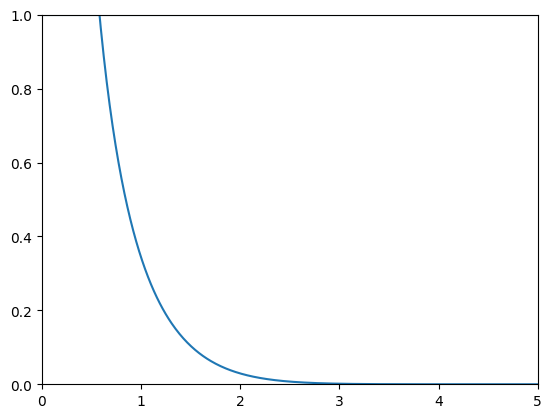

In [34]:
xx = np.linspace(0.1, 10, 1000)
sa = 2 * Bohr2Ang
sb = sa
sig = 1 / np.sqrt(sa**2 + sb**2)
result = erf(sig*xx)  
plt.plot(xx,(1-result)/xx)
plt.axhline(1)
plt.xlim(0,5)
plt.ylim(0,1)

In [35]:
import pytest
from dptb.data.build import build_dataset
from dptb.data.dataset import DefaultDataset
from dptb.data.transforms import OrbitalMapper
from dptb.data import AtomicDataset, DataLoader, AtomicDataDict,AtomicData
from dptb.nn.nnsk import NNSK
from dptb.utils.torch_geometric import Batch
from dptb.nn.sktb.socbasic import get_soc_matrix_cubic_basis
import matplotlib.pyplot as plt
from dptb.utils.constants import Harte2eV, Bohr2Ang
import torch

In [36]:
# 过一遍代码内部的数据流
# 构建dataset
root_directory='.'
set_options = {
    "r_max": 6.0,
    "root": "./data",
    "prefix": "kpath",
    "get_eigenvalues": True,
    "get_Hamiltonian": False,
}
common_options={"basis": {"B": ["2s", "2p"], "N": ["2s", "2p"]}}
dataset = build_dataset(**set_options, **common_options)

# call data loader 拿到一个batch
dload= DataLoader(dataset, batch_size=1, shuffle=False)
batch = next(iter(dload))
batch = batch.to_dict()

/Users/aisiqg/Software/venv/pydptb/lib/python3.9/site-packages/torch/nested/__init__.py:58: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:180.)
  return torch._nested_tensor_from_tensor_list(tensor_list, dtype, None, device, None)
The cutoffs in data and model are not checked. be careful!


In [37]:
# 仿照代码内部对batch data 初始化操作
idp_sk = OrbitalMapper(basis={"B": ["2s", "2p"], "N": ["2s", "2p"]},method="sktb")
batch = AtomicDataDict.with_edge_vectors(batch, with_lengths=True)
idp_sk(batch)
data = batch

tensor([7, 7])

In [103]:
sigma_rep = {'B': 0.5, 'N': 0.5}
def atom_dict_to_atomic_tensor(chemical_symbol_to_type, sigma_dict):
    sigma_tensors = torch.zeros(len(chemical_symbol_to_type),dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type, sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_dict[isym] = sigma_tensors[ind]
    return sigma_dict


In [104]:
sigma_tensor = atom_dict_to_atomic_tensor(idp_sk.chemical_symbol_to_type,sigma_rep)
edge_index = data[AtomicDataDict.EDGE_TYPE_KEY].flatten()
edge_number = idp_sk.untransform_bond(edge_index).T
edge_atom_types = idp_sk.transform_atom(edge_number.flatten()).reshape(2, -1)

In [248]:

idp_sk.untransform_atom(data['atom_types'])

tensor([[7],
        [5]])

In [241]:
data[AtomicDataDict.EDGE_TYPE_KEY].shape
egtty = torch.tensor([0, 1, 3])
egtty_num = idp_sk.untransform_bond(egtty).T
idp_sk.transform_atom(egtty_num.flatten()).reshape(2, -1)

tensor([[0, 0, 1],
        [0, 1, 1]])

In [243]:
idp_sk.untransform_bond(egtty)

tensor([[5, 5],
        [5, 7],
        [7, 7]])

In [ ]:
idp_sk.untransform_bond(torch.tensor(3)).T
edge_atom_types

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
         0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
         0, 0, 0, 0, 0, 0]])

In [244]:
data[AtomicDataDict.EDGE_INDEX_KEY]

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
         1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1],
        [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
         1, 1, 1, 1, 1, 1]])

In [224]:
def untransform_bond(edge_index):
    # Mock implementation that returns predefined values
    mapbond ={0:[5,5], 1:[5,7],2:[7,5],3:[7,7]}
    edge_num = torch.tensor([mapbond[ii] for ii in edge_index.tolist()])
    return edge_num.T

In [ ]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [ ]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [ ]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [ ]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [ ]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [ ]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [ ]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [ ]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [ ]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [ ]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [ ]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [204]:
idp_sk.untransform_bond(torch.tensor(0)).T

tensor([5, 5])

In [195]:
edge_index

tensor([3, 2, 3, 2, 3, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 2,
        2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 3, 1, 3, 1, 3, 1, 1,
        1, 3, 1, 1, 1, 3, 1, 1, 1, 3, 1, 3, 1, 3, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0])

In [196]:
edge_number

tensor([[7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
         7, 7, 7, 7, 7, 7, 5, 5, 5, 5, 5, 5, 5, 5, 5, 7, 5, 7, 5, 7, 5, 7, 5, 5,
         5, 7, 5, 5, 5, 7, 5, 5, 5, 7, 5, 7, 5, 7, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5],
        [7, 5, 7, 5, 7, 5, 7, 5, 5, 5, 7, 5, 5, 5, 7, 5, 5, 5, 7, 5, 7, 5, 7, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 7, 7, 7, 7, 7, 7, 7, 7, 7,
         7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 5, 5, 5,
         5, 5, 5, 5, 5, 5]])

In [197]:
edge_atom_types

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
         0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
         0, 0, 0, 0, 0, 0]])

In [157]:
sigma_bond = sigma_tensor[edge_atom_types[0]] ** 2 + sigma_tensor[edge_atom_types[1]] ** 2
gamma_rep = Bohr2Ang * 1.0 / torch.sqrt(sigma_bond) # unit  1/Bohr

In [158]:
def atom_dict_to_atomic_tensor(chemical_symbol_to_type,sigma_dict):
    len_types_in_model = len(chemical_symbol_to_type)
    sigma_tensors = torch.zeros(len_types_in_model,dtype=torch.float32)
    for isym, ind in chemical_symbol_to_type.items():
        sigma_tensors[ind] = sigma_dict[isym]
    return sigma_tensors

def atom_tensor_to_atomic_dict(chemical_symbol_to_type,sigma_tensors):
    sigma_dict = {}
    for isym, ind in chemical_symbol_to_type.items():
        sigma_rep[isym] = sigma_tensors[ind]
    return sigma_dict

In [107]:
# erf(sigma_bond)
from scipy import constants
k_e = 1/(4*torch.pi*constants.epsilon_0)
R2E_factor = k_e * constants.e**2 / 10**-10 / constants.e # 1/R -> E, unit of eV

In [160]:
pot = 1.0 * Bohr2Ang /data[AtomicDataDict.EDGE_LENGTH_KEY] * ( 
        1 - erf(gamma_rep * data[AtomicDataDict.EDGE_LENGTH_KEY]/Bohr2Ang)
    )

In [ ]:
pot.shape 

torch.Size([78])

In [190]:
indsca = data['edge_index']

In [191]:
import torch_scatter
from torch_scatter import scatter_sum



In [192]:
node_energy = scatter_sum(pot, data['edge_index'][0], dim=0)

In [200]:
data['atom_types']

tensor([[1],
        [0]])

In [198]:
data['edge_index']

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
         1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1],
        [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
         1, 1, 1, 1, 1, 1]])

In [189]:
node_energy.shape

torch.Size([2])

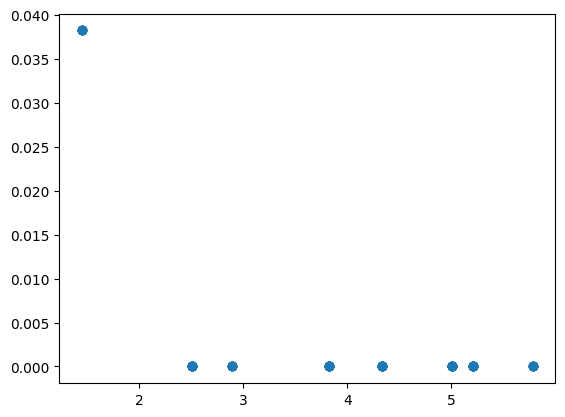

In [163]:
plt.plot(data[AtomicDataDict.EDGE_LENGTH_KEY], pot*Harte2eV,'o')
#plt.yscale('log')

(0.0, 400.0)

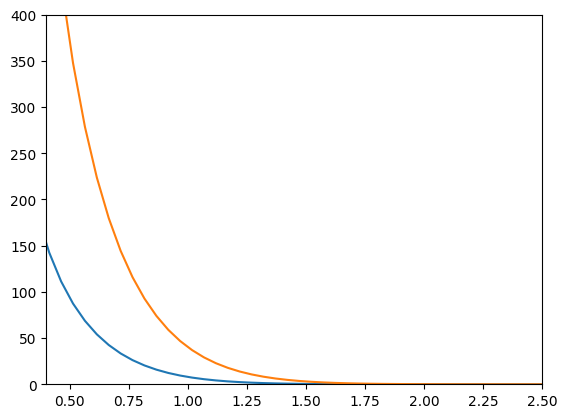

In [166]:
xx = np.linspace(0.01, 5, 100)
rr = Bohr2Ang * 1.0/xx * (1 - erf(1/np.sqrt(2*(1.0)) * xx/Bohr2Ang))
plt.plot(xx, 16*16*rr)
rr = Bohr2Ang * 1.0/xx * (1 - erf(1/np.sqrt(2*(1.2)) * xx/Bohr2Ang))
plt.plot(xx, 30*30*rr)
plt.xlim(0.4,2.5)
plt.ylim(0,400)

In [132]:
from ase.units import Bohr, Hartree


In [134]:
Bohr

0.5291772105638411